# 회귀 (Regression)

In [13]:
import numpy as np
import pandas as pd

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

In [14]:
# 공통 평가지표 계산
def evaluate_regression(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"r2": r2, "mae": mae, "rmse": rmse}

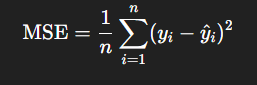

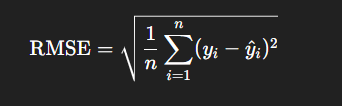

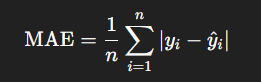

In [25]:

# 1) 데이터 로드
data = load_diabetes(as_frame=True)
df = data.frame.copy()
X = df.drop(columns=["target"])
y = df["target"]

In [26]:
df

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


In [17]:
# 2) train / val / test 분할
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Shapes:", X_train.shape, X_val.shape, X_test.shape)

Shapes: (265, 10) (88, 10) (89, 10)


In [29]:
X_test_1

,bmi
116,0.058463
82,-0.035307
327,0.114509
407,0.092953
388,-0.024529
...,...
415,0.008883
140,0.014272
399,0.022895
364,-0.006206


In [18]:
# A) 단순 선형회귀(단일 특성) - 컬럼 하나만 사용

single_feature = ["bmi"]
X_train_1 = X_train[single_feature]
X_val_1   = X_val[single_feature]
X_test_1  = X_test[single_feature]

lr_single = LinearRegression()
lr_single.fit(X_train_1, y_train)

val_pred = lr_single.predict(X_val_1)
test_pred = lr_single.predict(X_test_1)

print(evaluate_regression(y_val, val_pred))
print(evaluate_regression(y_test, test_pred))


{'r2': 0.35807192324505865, 'mae': 49.205121728237, 'rmse': np.float64(60.83306853752704)}
{'r2': 0.22294188943403737, 'mae': 55.210657137130205, 'rmse': np.float64(67.04404354626587)}


In [19]:
# B) 다중회귀(여러 특성) - 모든 특성 사용
lr_multi = LinearRegression()
lr_multi.fit(X_train, y_train)

val_pred = lr_multi.predict(X_val)
test_pred = lr_multi.predict(X_test)

print(evaluate_regression(y_val, val_pred))
print(evaluate_regression(y_test, test_pred))

{'r2': 0.5809667034070141, 'mae': 38.22127405114377, 'rmse': np.float64(49.14969247001349)}
{'r2': 0.4389137589815666, 'mae': 46.72401655139614, 'rmse': np.float64(56.970267692676664)}


# 다항회귀 어떻게 구현하지??

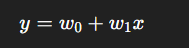

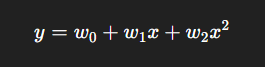

In [20]:
# C) 다항회귀(Polynomial Regression)
poly_degree = 2
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=False)), # 보통 회귀는 상수항 들어가서 굳이 넣을 필요 X
    ("lr", LinearRegression())
])

poly_model.fit(X_train, y_train)

val_pred = poly_model.predict(X_val)
test_pred = poly_model.predict(X_test)

print(evaluate_regression(y_val, val_pred))
print(evaluate_regression(y_test, test_pred))

{'r2': 0.41755481217394785, 'mae': 47.276965639890435, 'rmse': np.float64(57.94608094288006)}
{'r2': 0.4106135380059399, 'mae': 47.08183556189856, 'rmse': np.float64(58.389334939889366)}


# 규제 (Regularization)

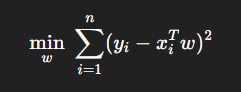

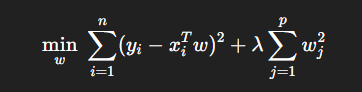

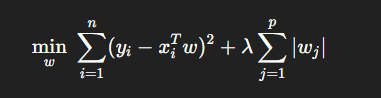

In [21]:
from sklearn.linear_model import Ridge

# D-1) Ridge Regression
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train, y_train)

val_pred = ridge.predict(X_val)
test_pred = ridge.predict(X_test)

print(evaluate_regression(y_val, val_pred))
print(evaluate_regression(y_test, test_pred))

{'r2': 0.4431419268359479, 'mae': 47.53504404160745, 'rmse': np.float64(56.65898603535078)}
{'r2': 0.3709064412384777, 'mae': 50.127087483900425, 'rmse': np.float64(60.32413037033285)}


In [22]:
from sklearn.linear_model import Lasso

# D-2) Lasso Regression
lasso = Lasso(alpha=0.01, random_state=42, max_iter=10000)
lasso.fit(X_train, y_train)

val_pred = lasso.predict(X_val)
test_pred = lasso.predict(X_test)

print(evaluate_regression(y_val, val_pred))
print(evaluate_regression(y_test, test_pred))

{'r2': 0.5784115114017325, 'mae': 38.381989151071245, 'rmse': np.float64(49.29931784826742)}
{'r2': 0.4317830349897033, 'mae': 46.99650799792051, 'rmse': np.float64(57.33113618342399)}


# 다항회귀에 pipeline과 grid search까지 써보기

In [23]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 0) 공통 평가 함수
def evaluate_regression(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse


# 1) 데이터
data = load_diabetes(as_frame=True)
X = data.data
y = data.target


# 2) train / test 먼저 분리 (gridsearch는 train에서 CV)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 3) 파이프라인
#    - 다항특성 생성 -> 스케일링 -> 선형회귀
pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("lr", LinearRegression())
])


# 4) 그리드 서치 설정
#    scoring은 R2 기준으로 최적화
param_grid = {
    "poly__degree": [1, 2, 3],  # 1이면 사실상 '다중 선형회귀'
    "poly__interaction_only": [False, True]
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV R2 : {grid.best_score_:.4f}")

best_model = grid.best_estimator_


# 5) 테스트 성능 평가
test_pred = best_model.predict(X_test)
r2, mae, rmse = evaluate_regression(y_test, test_pred)

print("\n[Best Model - TEST]")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

Best params: {'poly__degree': 1, 'poly__interaction_only': False}
Best CV R2 : 0.4493

[Best Model - TEST]
R2   : 0.4526
MAE  : 42.7941
RMSE : 53.8534


# 위 과정을 경사하강법으로 진행?

In [24]:
import numpy as np

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# 0) 평가 함수
def evaluate_regression(y_true, y_pred):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return r2, mae, rmse

# 1) 데이터
data = load_diabetes(as_frame=True)
X = data.data
y = data.target

# 2) train / test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) 파이프라인
pipe = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("scaler", StandardScaler()),
    ("sgd", SGDRegressor(random_state=42))
])

# 4) 그리드 설정
param_grid = {
    "poly__degree": [1, 2, 3],
    "poly__interaction_only": [False, True],

    "sgd__penalty": ["l2", "l1", "elasticnet"],
    "sgd__alpha": [0.0001, 0.001, 0.01],
    "sgd__max_iter": [1000, 2000],
    "sgd__learning_rate": ["constant", "optimal"],
    "sgd__eta0": [0.001, 0.01]  # constant일 때 사용
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print(f"Best CV R2 : {grid.best_score_:.4f}")

best_model = grid.best_estimator_

# 5) 테스트 성능 평가
test_pred = best_model.predict(X_test)

r2, mae, rmse = evaluate_regression(y_test, test_pred)

print("\n[Best Model - TEST]")
print(f"R2   : {r2:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")

Best params: {'poly__degree': 1, 'poly__interaction_only': False, 'sgd__alpha': 0.01, 'sgd__eta0': 0.001, 'sgd__learning_rate': 'constant', 'sgd__max_iter': 1000, 'sgd__penalty': 'l2'}
Best CV R2 : 0.4522

[Best Model - TEST]
R2   : 0.4559
MAE  : 42.9018
RMSE : 53.6925


## 주요 하이퍼파라미터
1. loss

- 기본값: 'squared_error'

- squared_error → 일반 선형회귀

- huber → 이상치에 강함


2. penalty

- 규제 방식

- 'l2' → Ridge

- 'l1' → Lasso

- 'elasticnet' → 둘 다

- None → 정규화 없음

3. alpha

- 규제 강도 (λ)

- 값이 클수록:

- 가중치 작아짐, 과적합 감소, bias 증가

4. learning_rate

- 학습률 전략

- 'constant'
  - 항상 같은 학습률 사용

- 'optimal' (기본값)
  - 점점 감소하는 학습율
  - 이론적으로 수렴 보장, 자동으로 적절히 감소, 안정적

- 'invscaling'
  - 점진적 감소
  - optimal보다 감소 속도 조절 가능(power_t의 기본값 0.25인데 이걸로 조절 가능)

- 'adaptive'
  - 초기에는 constant처럼 유지
  - 검증 결과가 개선되지 않으면 학습율을 줄임

5. eta0

- 초기 학습률

- learning_rate='constant' 일 때 중요

6. max_iter

- 최대 반복 횟수

- SGD는 반복 학습이라 매우 중요

7. tol

- 수렴 조건

- 변화량이 tol보다 작으면 중단

8. early_stopping

- True로 하면:

- 내부 validation split

- 성능 나빠지면 자동 종료

- 딥러닝 느낌의 안정성 옵션